# Haciendo "scrapping" de los datos (Conversión del json a csv)

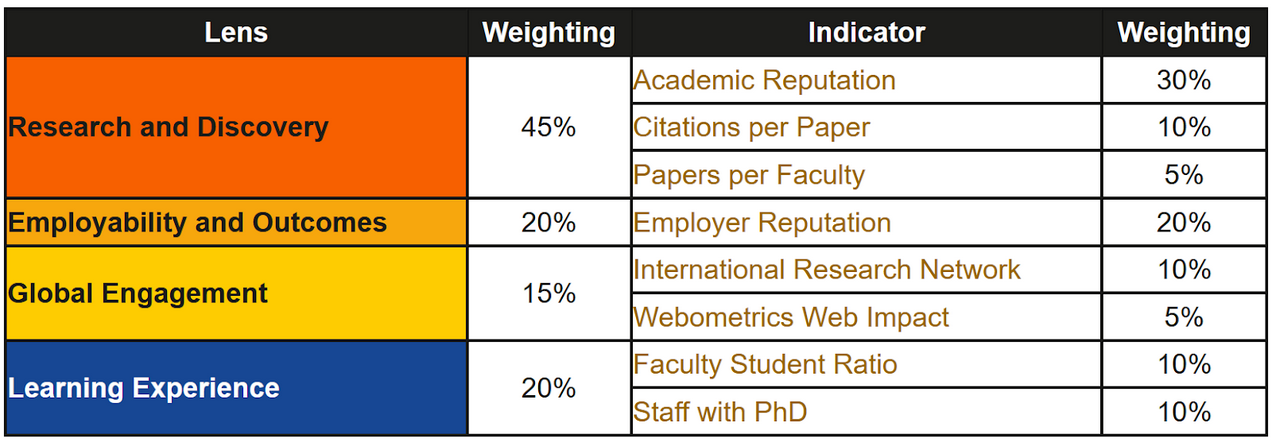

In [ ]:
import json
import csv

def json_to_csv(json_file_path, csv_file_path):
    # Leer el archivo JSON
    with open(json_file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)

    # Obtener la lista de universidades
    universities = data['score_nodes']

    # Definir los campos del CSV
    fieldnames = [
        'rank', 'nid', 'title', 'city', 'overall_score', 'rank_display',
        'academic_reputation_score', 'academic_reputation_rank',
        'employer_reputation_score', 'employer_reputation_rank',
        'faculty_student_ratio_score', 'faculty_student_ratio_rank',
        'staff_phd_score', 'staff_phd_rank',
        'citations_per_paper_score', 'citations_per_paper_rank',
        'papers_per_faculty_score', 'papers_per_faculty_rank',
        'international_research_network_score', 'international_research_network_rank',
        'web_impact_score', 'web_impact_rank',
        'scholarship', 'student_mix_domestic', 'student_mix_international'
    ]

    # Crear y escribir el archivo CSV
    with open(csv_file_path, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()

        for uni in universities:
            # Extraer información básica
            row = {
                'rank': uni.get('rank', ''),
                'nid': uni.get('nid', ''),
                'title': uni.get('title', ''),
                'city': uni.get('city', ''),
                'overall_score': uni.get('overall_score', ''),
                'rank_display': uni.get('rank_display', '')
            }

            # Extraer información de más info
            more_info = uni.get('more_info', [])
            scholarship = ''
            student_mix = ''

            for info in more_info:
                if info.get('label') == 'Scholarship':
                    scholarship = info.get('value', '')
                elif info.get('label') == 'Student Mix':
                    student_mix = info.get('value', '')

            # Procesar student mix
            domestic_percent = ''
            international_percent = ''
            if student_mix:
                parts = student_mix.split('International')
                if len(parts) == 2:
                    domestic_part = parts[0].replace('Domestic', '').strip()
                    international_part = parts[1].strip()
                    domestic_percent = domestic_part
                    international_percent = international_part

            row['scholarship'] = scholarship
            row['student_mix_domestic'] = domestic_percent
            row['student_mix_international'] = international_percent

            # Extraer scores por categoría
            scores = uni.get('scores', {})

            # Academic Reputation
            research_scores = scores.get('Research \u0026 Discovery', [])
            for score in research_scores:
                if score.get('indicator_name') == 'Academic Reputation':
                    row['academic_reputation_score'] = score.get('score', '')
                    row['academic_reputation_rank'] = score.get('rank', '')

            # Employer Reputation
            employability_scores = scores.get('Employability', [])
            for score in employability_scores:
                if score.get('indicator_name') == 'Employer Reputation':
                    row['employer_reputation_score'] = score.get('score', '')
                    row['employer_reputation_rank'] = score.get('rank', '')

            # Learning Experience scores
            learning_scores = scores.get('Learning Experience', [])
            for score in learning_scores:
                if score.get('indicator_name') == 'Faculty Student Ratio':
                    row['faculty_student_ratio_score'] = score.get('score', '')
                    row['faculty_student_ratio_rank'] = score.get('rank', '')
                elif score.get('indicator_name') == 'Staff with PhD':
                    row['staff_phd_score'] = score.get('score', '')
                    row['staff_phd_rank'] = score.get('rank', '')

            # Research scores
            for score in research_scores:
                if score.get('indicator_name') == 'Citations per Paper':
                    row['citations_per_paper_score'] = score.get('score', '')
                    row['citations_per_paper_rank'] = score.get('rank', '')
                elif score.get('indicator_name') == 'Papers per Faculty':
                    row['papers_per_faculty_score'] = score.get('score', '')
                    row['papers_per_faculty_rank'] = score.get('rank', '')

            # Global Engagement scores
            global_scores = scores.get('Global Engagement', [])
            for score in global_scores:
                if score.get('indicator_name') == 'International Research Network':
                    row['international_research_network_score'] = score.get('score', '')
                    row['international_research_network_rank'] = score.get('rank', '')
                elif score.get('indicator_name') == 'Web Impact':
                    row['web_impact_score'] = score.get('score', '')
                    row['web_impact_rank'] = score.get('rank', '')

            # Escribir la fila
            writer.writerow(row)

    print(f"CSV creado exitosamente: {csv_file_path}")
    print(f"Total de universidades procesadas: {len(universities)}")

# Uso del script
if __name__ == "__main__":
    # Especifica las rutas de tus archivos
    json_file_path = "datos_qs_latam_brutos.json"
    csv_file_path = "datos_qs_latam_chile.csv"

    json_to_csv(json_file_path, csv_file_path)

CSV creado exitosamente: datos_qs_latam_chile.csv
Total de universidades procesadas: 41


# Limpiar el csv

In [ ]:
import pandas as pd

# La forma más simple
df = pd.read_csv("datos_qs_latam_chile.csv")

# Columnas a eliminar
columnas_eliminar = ['scholarship', 'nid', 'city']
columnas_eliminar.extend([col for col in df.columns if 'rank' in col.lower() and col != 'rank'])

# Eliminar y renombrar
df_limpio = df.drop(columns=columnas_eliminar).rename(columns={'rank': 'ranking'})

# Resetear el índice para que el ranking empiece en 1 y sea secuencial
df_limpio = df_limpio.reset_index(drop=True)
df_limpio['ranking'] = df_limpio.index + 1

# Guardar
df_limpio.to_csv("datos_qs_latam_chile_limpio.csv", index=False)

print("CSV 'datos_qs_latam_chile_limpio' creado")

CSV 'datos_qs_latam_chile_limpio' creado


# Visualización del csv resultante (Chile)

In [ ]:
import pandas as pd

# Carga el archivo CSV en un DataFrame
df = pd.read_csv('datos_qs_latam_chile_limpio.csv')

# Aplica un estilo de gradiente de color a las columnas numéricas del DataFrame filtrado
styled_df = df.style.background_gradient(cmap='Blues')

# 5. Muestra el DataFrame con el estilo aplicado
styled_df

,ranking,title,overall_score,academic_reputation_score,employer_reputation_score,faculty_student_ratio_score,staff_phd_score,citations_per_paper_score,papers_per_faculty_score,international_research_network_score,web_impact_score,student_mix_domestic,student_mix_international
0,1,Pontificia Universidad Católica de Chile (UC),100.000000,100.000000,100.000000,65.200000,98.300000,76.700000,96.800000,99.800000,95.700000,95%,5%
1,2,Universidad de Chile,92.500000,100.000000,100.000000,22.300000,69.200000,75.700000,99.400000,99.700000,100.000000,95%,5%
2,3,Universidad de Concepción,87.100000,89.200000,88.700000,37.000000,60.400000,89.800000,88.900000,98.700000,82.500000,98%,2%
3,4,Universidad de Santiago de Chile (USACH),81.400000,96.900000,96.900000,24.000000,29.000000,57.700000,80.600000,96.700000,63.700000,98%,2%
4,5,Universidad Adolfo Ibáñez,77.100000,80.000000,99.000000,19.500000,81.300000,28.400000,96.400000,86.800000,43.600000,95%,5%
5,6,Pontificia Universidad Católica de Valparaíso,76.400000,89.000000,81.400000,14.800000,60.700000,45.400000,99.100000,92.700000,50.300000,98%,2%
6,7,Universidad Austral de Chile,67.200000,65.500000,59.500000,9.100000,85.000000,49.800000,99.300000,93.900000,59.400000,99%,1%
7,8,Universidad Diego Portales (UDP),64.600000,64.900000,79.200000,24.200000,14.400000,87.300000,46.000000,88.900000,34.800000,96%,4%
8,9,Universidad de los Andes - Chile,63.400000,72.600000,90.200000,29.200000,28.100000,36.000000,58.200000,64.300000,25.800000,98%,2%
9,10,Universidad Técnica Federico Santa María (USM),62.500000,51.100000,83.400000,10.000000,46.300000,67.700000,80.200000,94.100000,22.500000,99%,1%


# Simulación del ranking con los pesos entregados por QS

In [ ]:
import pandas as pd
import numpy as np

# Leer el archivo CSV
df = pd.read_csv('datos_qs_latam_chile_limpio.csv')

# Pesos según la imagen
pesos = {
    'academic_reputation_score': 0.30,      # 30%
    'employer_reputation_score': 0.20,      # 20%
    'faculty_student_ratio_score': 0.10,    # 10%
    'staff_phd_score': 0.10,                # 10%
    'citations_per_paper_score': 0.10,      # 10%
    'international_research_network_score': 0.10,  # 10%
    'papers_per_faculty_score': 0.05,       # 5%
    'web_impact_score': 0.05                # 5%
}

def calcular_ranking_simple(df, pesos):
    df_ranking = df.copy()

    # Convertir a numérico
    for columna in pesos.keys():
        df_ranking[columna] = pd.to_numeric(df_ranking[columna], errors='coerce')

    # Calcular score ponderado
    df_ranking['Overall_calculado'] = 0
    for columna, peso in pesos.items():
        scores = df_ranking[columna].fillna(0)
        df_ranking['Overall_calculado'] += scores * peso

    # Ordenar y asignar ranking
    df_ranking = df_ranking.sort_values('Overall_calculado', ascending=False)
    df_ranking['Ranking_calculado'] = range(1, len(df_ranking) + 1)
    df_ranking['Diferencia'] = df_ranking['ranking'] - df_ranking['Ranking_calculado']

    return df_ranking

# Calcular y guardar
df_resultado = calcular_ranking_simple(df, pesos)
df_resultado.to_csv('ranking_qs_latam_chile_calculado.csv', index=False)

print("Ranking calculado y guardado")

Ranking calculado y guardado


# Análisis estadístico de los resultados obtenidos

In [ ]:
import pandas as pd
from scipy.stats import spearmanr, kendalltau

# Leer el archivo con los resultados calculados
df_resultados = pd.read_csv('ranking_qs_latam_chile_calculado.csv')

# Calcular correlación de Spearman (para rankings)
spearman_corr, spearman_p = spearmanr(df_resultados['ranking'], df_resultados['Ranking_calculado'])

# Calcular correlación de Kendall Tau (para rankings)
kendall_tau, kendall_p = kendalltau(df_resultados['ranking'], df_resultados['Ranking_calculado'])

# Calcular diferencia absoluta promedio
diferencia_promedio = df_resultados['Diferencia'].abs().mean()

# Calcular RMSE (Root Mean Square Error) de las diferencias
rmse = (df_resultados['Diferencia'] ** 2).mean() ** 0.5

print(f"Correlación de Spearman: {spearman_corr:.3f} (p-value: {spearman_p:.3f})")
print(f"Correlación de Kendall Tau: {kendall_tau:.3f} (p-value: {kendall_p:.3f})")
print(f"Diferencia absoluta promedio: {diferencia_promedio:.2f} puestos")
print(f"RMSE de las diferencias: {rmse:.2f} puestos")

Correlación de Spearman: 0.997 (p-value: 0.000)
Correlación de Kendall Tau: 0.976 (p-value: 0.000)
Diferencia absoluta promedio: 0.44 puestos
RMSE de las diferencias: 0.88 puestos


🎯 Significado de los Resultados
1. **Correlación de Spearman: 0.997**

    Escala: -1 a 1 (1 = correlación perfecta)

    Interpretación: 0.997 indica una correlación monotónica casi perfecta

    Significado: El orden de las universidades es prácticamente idéntico

2. **Correlación de Kendall Tau: 0.976**

    Escala: -1 a 1 (1 = concordancia perfecta)

    Interpretación: Concordancia muy fuerte en los pares de rankings

    Significado: Casi todos los pares de universidades mantienen el mismo orden relativo

3. **Diferencia Absoluta Promedio: 0.44 puestos**

    Interpretación: Error promedio de menos de medio puesto

    Contexto: En un ranking de ~40 universidades, esto es excelente

4. **RMSE: 0.88 puestos**

    Interpretación: Dispersión de errores muy baja

    Significado: Los pocos errores que existen son muy pequeños

# Comparación entre universidades

In [ ]:
import pandas as pd
import numpy as np

def comparar_universidades(df, uni1, uni2, variable_cambiar=None, mejora_porcentaje=0):
    """
    Compara dos universidades y simula cambios en variables específicas
    """
    # Filtrar las dos universidades
    mask1 = df['title'].str.contains(uni1, case=False, na=False)
    mask2 = df['title'].str.contains(uni2, case=False, na=False)

    if not mask1.any() or not mask2.any():
        print("❌ Una o ambas universidades no encontradas")
        print("   Universidades disponibles:")
        for nombre in df['title'].head(10):
            print(f"   - {nombre}")
        return None, None

    uni1_data = df[mask1].iloc[0]
    uni2_data = df[mask2].iloc[0]

    # Pesos para el cálculo (según especificación LATAM)
    pesos = {
        'academic_reputation_score': 0.30,      # 30%
        'employer_reputation_score': 0.20,      # 20%
        'faculty_student_ratio_score': 0.10,    # 10%
        'staff_phd_score': 0.10,                # 10%
        'citations_per_paper_score': 0.10,      # 10%
        'international_research_network_score': 0.10,  # 10%
        'papers_per_faculty_score': 0.05,       # 5%
        'web_impact_score': 0.05                # 5%
    }

    def calcular_score(row, variable_extra=None, valor_extra=None):
        score = 0
        for col, peso in pesos.items():
            # Convertir a numérico y manejar NaN
            valor = pd.to_numeric(row[col], errors='coerce')
            if pd.isna(valor):
                valor = 0

            if variable_extra and col == variable_extra:
                valor = valor_extra
            score += valor * peso
        return score

    # Scores actuales
    score1_actual = calcular_score(uni1_data)
    score2_actual = calcular_score(uni2_data)

    print("🎯 COMPARACIÓN 1 vs 1")
    print("=" * 70)
    print(f"🏫 {uni1_data['title']}")
    print(f"🏫 {uni2_data['title']}")
    print("=" * 70)

    # Mostrar scores actuales
    print(f"\n📊 SCORES ACTUALES:")
    print(f"   {uni1_data['title'][:30]:<30}: {score1_actual:.1f}")
    print(f"   {uni2_data['title'][:30]:<30}: {score2_actual:.1f}")

    if score1_actual > score2_actual:
        print(f"   🥇 {uni1_data['title'][:20]} lidera por {score1_actual - score2_actual:.1f} puntos")
    elif score2_actual > score1_actual:
        print(f"   🥇 {uni2_data['title'][:20]} lidera por {score2_actual - score1_actual:.1f} puntos")
    else:
        print(f"   ⚖️  Empate técnico")

    # Mostrar variables individuales
    print(f"\n🔍 VARIABLES INDIVIDUALES:")
    print(f"   {'Variable':<25} {'Uni1':>6} {'Uni2':>6} {'Diferencia':>12}")
    print(f"   {'-'*25} {'-'*6} {'-'*6} {'-'*12}")

    for col in pesos.keys():
        val1 = pd.to_numeric(uni1_data[col], errors='coerce')
        val2 = pd.to_numeric(uni2_data[col], errors='coerce')

        if pd.isna(val1):
            val1 = 0
        if pd.isna(val2):
            val2 = 0

        dif = val1 - val2
        flecha = "↑" if dif > 0 else "↓" if dif < 0 else "="
        print(f"   {col:<25} {val1:>6.1f} {val2:>6.1f} {flecha} {abs(dif):>10.1f}")

    # Simular cambio si se especifica
    if variable_cambiar and variable_cambiar in pesos:
        print(f"\n🔄 SIMULACIÓN: {uni1_data['title'][:20]} mejora en {variable_cambiar}")
        print("-" * 60)

        # Calcular nuevo valor
        valor_actual = pd.to_numeric(uni1_data[variable_cambiar], errors='coerce')
        if pd.isna(valor_actual):
            valor_actual = 0

        nuevo_valor = valor_actual * (1 + mejora_porcentaje/100)

        # Scores con mejora
        score1_mejorado = calcular_score(uni1_data, variable_cambiar, nuevo_valor)

        print(f"   Valor actual {variable_cambiar}: {valor_actual:.1f}")
        print(f"   Valor mejorado (+{mejora_porcentaje}%): {nuevo_valor:.1f}")
        print(f"   Score actual: {score1_actual:.1f}")
        print(f"   Score mejorado: {score1_mejorado:.1f}")
        print(f"   Ganancia: +{(score1_mejorado - score1_actual):.2f} puntos")

        # Verificar si cambia el ranking
        if score1_mejorado > score2_actual and score1_actual <= score2_actual:
            print(f"   🎉 ¡CAMBIO DE POSICIÓN! Ahora supera a {uni2_data['title'][:20]}")
        elif score1_mejorado > score2_actual:
            print(f"   📈 Amplía su ventaja sobre {uni2_data['title'][:20]}")
        else:
            print(f"   ⚠️  Sigue por debajo de {uni2_data['title'][:20]}")
            puntos_necesarios = score2_actual - score1_mejorado
            print(f"   💡 Necesita {puntos_necesarios:.2f} puntos más para superarla")

    # Análisis de variables críticas
    print(f"\n📈 VARIABLES CRÍTICAS PARA {uni1_data['title'][:20]}:")
    variables_importantes = []

    for col, peso in pesos.items():
        val1 = pd.to_numeric(uni1_data[col], errors='coerce')
        val2 = pd.to_numeric(uni2_data[col], errors='coerce')

        if pd.isna(val1):
            val1 = 0
        if pd.isna(val2):
            val2 = 0

        dif_actual = val2 - val1  # Diferencia a favor de uni2
        if dif_actual > 0:  # La otra universidad tiene mejor score
            puntos_para_igualar = dif_actual * peso
            variables_importantes.append((col, dif_actual, puntos_para_igualar))

    # Ordenar por impacto potencial
    variables_importantes.sort(key=lambda x: x[2], reverse=True)

    print(f"   Si mejora estas variables, ganaría puntos contra {uni2_data['title'][:20]}:")
    for col, dif_actual, puntos_ganados in variables_importantes[:3]:  # Top 3 más importantes
        print(f"   • {col:<25}: +{dif_actual:.1f} pts → +{puntos_ganados:.3f} pts totales")

    return uni1_data, uni2_data

def comparador_interactivo():
    """
    Versión interactiva para comparar cualquier par de universidades
    """
    try:
        df = pd.read_csv('ranking_qs_latam_chile_calculado.csv')
    except FileNotFoundError:
        print("❌ Archivo 'ranking_qs_chile_calculado.csv' no encontrado")
        print("   Asegúrate de que el archivo esté en la misma carpeta")
        return

    while True:
        print("\n" + "="*80)
        print("🏫 COMPARADOR INTERACTIVO DE UNIVERSIDADES CHILENAS QS")
        print("="*80)

        print("\n📋 UNIVERSIDADES DISPONIBLES:")
        universidades = df['title'].tolist()
        for i, nombre in enumerate(universidades, 1):
            print(f"   {i:2d}. {nombre}")

        print("\n🔍 Ingresa los nombres (puedes usar parte del nombre):")
        uni1 = input("Universidad 1: ").strip()
        if uni1.lower() == 'salir':
            break

        uni2 = input("Universidad 2: ").strip()
        if uni2.lower() == 'salir':
            break

        print("\n🔄 ¿Quieres simular una mejora? (s/n/salir)")
        simular = input().strip().lower()
        if simular == 'salir':
            break

        variable = None
        porcentaje = 0

        if simular == 's':
            print("\n📊 Variables disponibles:")
            variables = list(pesos.keys())
            for i, var in enumerate(variables, 1):
                print(f"   {i}. {var}")

            try:
                opcion = int(input("Selecciona variable (número): ")) - 1
                if 0 <= opcion < len(variables):
                    variable = variables[opcion]
                    porcentaje = float(input("Porcentaje de mejora (ej: 10 para 10%): "))
                else:
                    print("❌ Número fuera de rango, continuando sin simulación...")
            except:
                print("❌ Opción inválida, continuando sin simulación...")

        print("\n" + "="*80)
        comparar_universidades(df, uni1, uni2, variable, porcentaje)

        print("\n¿Quieres hacer otra comparación? (s/n)")
        continuar = input().strip().lower()
        if continuar != 's':
            break

# Función para comparación directa
def comparacion_rapida(uni1, uni2, archivo='ranking_qs_chile_calculado.csv'):
    """
    Función para comparación rápida sin modo interactivo
    """
    df = pd.read_csv(archivo)
    return comparar_universidades(df, uni1, uni2)

# Ejecutar comparador interactivo
if __name__ == "__main__":
    print("🚀 INICIANDO COMPARADOR DE UNIVERSIDADES CHILENAS")
    comparador_interactivo()

🚀 INICIANDO COMPARADOR DE UNIVERSIDADES CHILENAS

🏫 COMPARADOR INTERACTIVO DE UNIVERSIDADES CHILENAS QS

📋 UNIVERSIDADES DISPONIBLES:
    1. Pontificia Universidad Católica de Chile (UC)
    2. Universidad de Chile
    3. Universidad de Concepción
    4. Universidad de Santiago de Chile (USACH)
    5. Universidad Adolfo Ibáñez
    6. Pontificia Universidad Católica de Valparaíso
    7. Universidad Austral de Chile
    8. Universidad Diego Portales (UDP)
    9. Universidad de los Andes - Chile
   10. Universidad Técnica Federico Santa María (USM)
   11. Universidad de Talca
   12. Universidad de La Frontera (UFRO)
   13. Universidad Andrés Bello
   14. Universidad del Desarrollo (UDD)
   15. Universidad de Valparaíso (UV)
   16. Universidad del Bío-Bío
   17. Universidad Autónoma de Chile
   18. Universidad Católica del Norte
   19. Universidad de Tarapaca
   20. Universidad Alberto Hurtado
   21. Universidad de La Serena
   22. Universidad de Antofagasta
   23. Universidad Católica de 

# Análisis avanzado (experimental)

In [ ]:
import pandas as pd
import numpy as np

def analisis_estrategico_avanzado(uni1_data, uni2_data, pesos, nombre_uni1, nombre_uni2):
    """
    Análisis que considera: impacto, dificultad y potencial real
    """

    # Definir dificultad de mejora por tipo de variable
    dificultad = {
        'academic_reputation_score': 0.9,        # Muy difícil - toma años construir
        'employer_reputation_score': 0.8,        # Difícil - relaciones con empresas
        'citations_per_paper_score': 0.7,        # Media-alta - publicaciones de calidad
        'international_research_network_score': 0.6,  # Media - colaboraciones
        'staff_phd_score': 0.5,                  # Media - contratar doctores
        'faculty_student_ratio_score': 0.4,      # Media-baja - contratar profesores
        'papers_per_faculty_score': 0.3,         # Baja-media - incentivar publicación
        'web_impact_score': 0.2                  # Baja - mejorar presencia web
    }

    estrategias = []

    for col, peso in pesos.items():
        # Convertir a numérico y manejar NaN
        valor_uni1 = pd.to_numeric(uni1_data[col], errors='coerce')
        valor_uni2 = pd.to_numeric(uni2_data[col], errors='coerce')

        if pd.isna(valor_uni1):
            valor_uni1 = 0
        if pd.isna(valor_uni2):
            valor_uni2 = 0

        diferencia = valor_uni2 - valor_uni1

        # Calcular mejora máxima realista (depende de la dificultad)
        mejora_maxima_realista = (100 - valor_uni1) * (1 - dificultad[col])
        mejora_optima = min(abs(diferencia), mejora_maxima_realista) if diferencia > 0 else mejora_maxima_realista * 0.5

        impacto = mejora_optima * peso
        eficiencia = impacto / (dificultad[col] + 0.1)  # +0.1 para evitar división por 0

        if diferencia > 0:  # Vamos detrás
            estrategias.append((col, diferencia, impacto, eficiencia, "RECUPERAR", mejora_optima))
        else:  # Vamos adelante
            estrategias.append((col, abs(diferencia), impacto, eficiencia, "CONSOLIDAR", mejora_optima))

    # Ordenar por eficiencia (impacto/dificultad)
    estrategias.sort(key=lambda x: x[3], reverse=True)

    print(f"\n🎯 RUTA ESTRATÉGICA ÓPTIMA PARA {nombre_uni1}")
    print("=" * 70)
    print("┌──────────────────────────┬──────────┬──────────┬──────────┬────────────┬──────────┐")
    print(f"│ {'Variable':<24} │ {'Brecha':>8} │ {'Impacto':>8} │ {'Eff':>6} │ {'Acción':<10} │ {'Meta':>8} │")
    print("├──────────────────────────┼──────────┼──────────┼──────────┼────────────┼──────────┤")

    for col, brecha, impacto, eff, accion, meta in estrategias[:6]:
        nombre_corto = col[:24]
        print(f"│ {nombre_corto:<24} │ {brecha:>8.1f} │ {impacto:>8.3f} │ {eff:>6.1f} │ {accion:<10} │ {meta:>7.1f} │")

    print("└──────────────────────────┴──────────┴──────────┴──────────┴────────────┴──────────┘")

    # Recomendación principal
    if estrategias:
        mejor_opcion = estrategias[0]
        print(f"\n💡 RECOMENDACIÓN PRINCIPAL: Enfócate en {mejor_opcion[0]}")
        print(f"   📊 Justificación:")
        print(f"   - Eficiencia: {mejor_opcion[3]:.1f} (impacto vs dificultad)")
        print(f"   - Meta realista: +{mejor_opcion[5]:.1f} puntos")
        print(f"   - Impacto en ranking: +{mejor_opcion[2]:.3f} puntos")

        # Análisis de escenarios
        print(f"\n📈 ESCENARIOS ESTRATÉGICOS:")

        # Escenario conservador (top 3 más eficientes)
        impacto_total = sum(estrategia[2] for estrategia in estrategias[:3])
        print(f"   🟢 ESCENARIO CONSERVADOR (1 año):")
        print(f"      Invertir en top 3 variables más eficientes")
        print(f"      Ganancia estimada: +{impacto_total:.2f} puntos")

        # Escenario agresivo (top 6)
        print(f"   🟡 ESCENARIO AGRESIVO (2-3 años):")
        impacto_total_agresivo = sum(estrategia[2] for estrategia in estrategias[:6])
        print(f"      Inversión integral en 6 variables clave")
        print(f"      Ganancia estimada: +{impacto_total_agresivo:.2f} puntos")

        # Puntos necesarios para superar
        score_actual_uni1 = sum(pd.to_numeric(uni1_data[col], errors='coerce') * peso for col, peso in pesos.items())
        score_actual_uni2 = sum(pd.to_numeric(uni2_data[col], errors='coerce') * peso for col, peso in pesos.items())
        puntos_para_superar = score_actual_uni2 - score_actual_uni1

        if puntos_para_superar > 0:
            print(f"\n🎯 OBJETIVO: Superar a {nombre_uni2}")
            print(f"   - Necesitas: +{puntos_para_superar:.2f} puntos")
            print(f"   - Con escenario conservador: {'✅ POSIBLE' if impacto_total >= puntos_para_superar else '⚠️  PARCIAL'}")
            print(f"   - Con escenario agresivo: {'✅ GARANTIZADO' if impacto_total_agresivo >= puntos_para_superar else '✅ POSIBLE'}")

        # Variables a evitar (baja eficiencia)
        variables_baja_eff = [e for e in estrategias if e[3] < 0.5]
        if variables_baja_eff:
            print(f"\n🚫 VARIABLES DE BAJA PRIORIDAD:")
            for var in variables_baja_eff[-3:]:  # Las 3 menos eficientes
                print(f"   - {var[0]} (Eff: {var[3]:.1f})")

def comparar_universidades(df, uni1, uni2, variable_cambiar=None, mejora_porcentaje=0):
    """
    Compara dos universidades y simula cambios en variables específicas
    """
    # Filtrar las dos universidades
    mask1 = df['title'].str.contains(uni1, case=False, na=False)
    mask2 = df['title'].str.contains(uni2, case=False, na=False)

    if not mask1.any() or not mask2.any():
        print("❌ Una o ambas universidades no encontradas")
        print("   Algunas universidades disponibles:")
        for nombre in df['title'].head(10):
            print(f"   - {nombre}")
        return None, None

    uni1_data = df[mask1].iloc[0]
    uni2_data = df[mask2].iloc[0]

    # Obtener nombres completos
    nombre_uni1 = uni1_data['title']
    nombre_uni2 = uni2_data['title']

    # Pesos para el cálculo (según especificación LATAM)
    pesos = {
        'academic_reputation_score': 0.30,      # 30%
        'employer_reputation_score': 0.20,      # 20%
        'faculty_student_ratio_score': 0.10,    # 10%
        'staff_phd_score': 0.10,                # 10%
        'citations_per_paper_score': 0.10,      # 10%
        'international_research_network_score': 0.10,  # 10%
        'papers_per_faculty_score': 0.05,       # 5%
        'web_impact_score': 0.05                # 5%
    }

    def calcular_score(row, variable_extra=None, valor_extra=None):
        score = 0
        for col, peso in pesos.items():
            # Convertir a numérico y manejar NaN
            valor = pd.to_numeric(row[col], errors='coerce')
            if pd.isna(valor):
                valor = 0

            if variable_extra and col == variable_extra:
                valor = valor_extra
            score += valor * peso
        return score

    # Scores actuales
    score1_actual = calcular_score(uni1_data)
    score2_actual = calcular_score(uni2_data)

    print("🎯 COMPARACIÓN 1 vs 1")
    print("=" * 80)
    print(f"🏫 {nombre_uni1}")
    print(f"🏫 {nombre_uni2}")
    print("=" * 80)

    # Mostrar scores actuales
    print(f"\n📊 SCORES ACTUALES:")
    print(f"   {nombre_uni1:<50}: {score1_actual:>6.1f}")
    print(f"   {nombre_uni2:<50}: {score2_actual:>6.1f}")

    if score1_actual > score2_actual:
        print(f"   🥇 {nombre_uni1} lidera por {score1_actual - score2_actual:.1f} puntos")
    elif score2_actual > score1_actual:
        print(f"   🥇 {nombre_uni2} lidera por {score2_actual - score1_actual:.1f} puntos")
    else:
        print(f"   ⚖️  Empate técnico")

    # Mostrar variables individuales - TABLA MEJORADA
    print(f"\n🔍 VARIABLES INDIVIDUALES:")
    print("┌" + "─" * 30 + "┬" + "─" * 10 + "┬" + "─" * 10 + "┬" + "─" * 12 + "┐")
    print(f"│ {'Variable':<28} │ {nombre_uni1[:8]:>8} │ {nombre_uni2[:8]:>8} │ {'Diferencia':>10} │")
    print("├" + "─" * 30 + "┼" + "─" * 10 + "┼" + "─" * 10 + "┼" + "─" * 12 + "┤")

    for col in pesos.keys():
        val1 = pd.to_numeric(uni1_data[col], errors='coerce')
        val2 = pd.to_numeric(uni2_data[col], errors='coerce')

        if pd.isna(val1):
            val1 = 0
        if pd.isna(val2):
            val2 = 0

        dif = val1 - val2
        flecha = "🟢 ↑" if dif > 0 else "🔴 ↓" if dif < 0 else "⚪ ="

        # Formatear nombres de variables más cortos
        nombre_corto = col.replace('_score', '').replace('_', ' ').title()
        if len(nombre_corto) > 28:
            nombre_corto = nombre_corto[:25] + "..."

        print(f"│ {nombre_corto:<28} │ {val1:>8.1f} │ {val2:>8.1f} │ {flecha} {abs(dif):>8.1f} │")

    print("└" + "─" * 30 + "┴" + "─" * 10 + "┴" + "─" * 10 + "┴" + "─" * 12 + "┘")

    # Simular cambio si se especifica
    if variable_cambiar and variable_cambiar in pesos:
        print(f"\n🔄 SIMULACIÓN: {nombre_uni1} mejora en {variable_cambiar}")
        print("─" * 60)

        # Calcular nuevo valor
        valor_actual = pd.to_numeric(uni1_data[variable_cambiar], errors='coerce')
        if pd.isna(valor_actual):
            valor_actual = 0

        nuevo_valor = valor_actual * (1 + mejora_porcentaje/100)
        # Asegurar que no exceda 100
        nuevo_valor = min(nuevo_valor, 100)

        # Scores con mejora
        score1_mejorado = calcular_score(uni1_data, variable_cambiar, nuevo_valor)

        print(f"   Valor actual: {valor_actual:.1f}")
        print(f"   Valor mejorado (+{mejora_porcentaje}%): {nuevo_valor:.1f}")
        print(f"   Score actual: {score1_actual:.1f}")
        print(f"   Score mejorado: {score1_mejorado:.1f}")
        print(f"   Ganancia: +{(score1_mejorado - score1_actual):.2f} puntos")

        # Verificar si cambia el ranking
        if score1_mejorado > score2_actual and score1_actual <= score2_actual:
            print(f"   🎉 ¡CAMBIO DE POSICIÓN! Ahora supera a {nombre_uni2}")
        elif score1_mejorado > score2_actual:
            print(f"   📈 Amplía su ventaja sobre {nombre_uni2}")
        else:
            print(f"   ⚠️  Sigue por debajo de {nombre_uni2}")
            puntos_necesarios = score2_actual - score1_mejorado
            print(f"   💡 Necesita {puntos_necesarios:.2f} puntos más para superarla")

    # ANÁLISIS ESTRATÉGICO AVANZADO
    analisis_estrategico_avanzado(uni1_data, uni2_data, pesos, nombre_uni1, nombre_uni2)

    return uni1_data, uni2_data

def comparador_interactivo():
    """
    Versión interactiva para comparar cualquier par de universidades
    """
    try:
        df = pd.read_csv('ranking_qs_latam_chile_calculado.csv')
        print("✅ Datos cargados correctamente")
        print(f"📊 Total de universidades: {len(df)}")
    except FileNotFoundError:
        print("❌ Error: No se encontró el archivo 'ranking_qs_latam_chile_calculado.csv'")
        print("💡 Asegúrate de que el archivo esté en la misma carpeta")
        return

    # Pesos para mostrar en el menú
    pesos = {
        'academic_reputation_score': 0.30,
        'employer_reputation_score': 0.20,
        'faculty_student_ratio_score': 0.10,
        'staff_phd_score': 0.10,
        'citations_per_paper_score': 0.10,
        'international_research_network_score': 0.10,
        'papers_per_faculty_score': 0.05,
        'web_impact_score': 0.05
    }

    while True:
        print("\n" + "="*80)
        print("🏫 COMPARADOR INTERACTIVO DE UNIVERSIDADES CHILENAS QS LATAM")
        print("="*80)

        print("\n📋 UNIVERSIDADES DISPONIBLES:")
        universidades = df['title'].tolist()
        for i, nombre in enumerate(universidades, 1):
            print(f"   {i:2d}. {nombre}")

        print("\n🔍 Ingresa los nombres (puedes usar parte del nombre):")
        uni1 = input("Universidad 1: ").strip()
        if uni1.lower() == 'salir':
            break

        uni2 = input("Universidad 2: ").strip()
        if uni2.lower() == 'salir':
            break

        print("\n🔄 ¿Quieres simular una mejora? (s/n/salir)")
        simular = input().strip().lower()
        if simular == 'salir':
            break

        variable = None
        porcentaje = 0

        if simular == 's':
            print("\n📊 Variables disponibles:")
            variables = list(pesos.keys())
            for i, var in enumerate(variables, 1):
                nombre_bonito = var.replace('_score', '').replace('_', ' ').title()
                peso_porcentaje = pesos[var] * 100
                print(f"   {i}. {nombre_bonito} ({peso_porcentaje}%)")

            try:
                opcion = int(input("Selecciona variable (número): ")) - 1
                if 0 <= opcion < len(variables):
                    variable = variables[opcion]
                    porcentaje = float(input("Porcentaje de mejora (ej: 10 para 10%): "))
                else:
                    print("❌ Número fuera de rango, continuando sin simulación...")
            except:
                print("❌ Opción inválida, continuando sin simulación...")

        print("\n" + "="*80)
        comparar_universidades(df, uni1, uni2, variable, porcentaje)

        print("\n¿Quieres hacer otra comparación? (s/n)")
        continuar = input().strip().lower()
        if continuar != 's':
            break

# Función para comparación directa
def comparacion_rapida(uni1, uni2, archivo='ranking_qs_latam_chile_calculado.csv'):
    """
    Función para comparación rápida sin modo interactivo
    """
    try:
        df = pd.read_csv(archivo)
        return comparar_universidades(df, uni1, uni2)
    except FileNotFoundError:
        print(f"❌ No se encontró el archivo {archivo}")
        return None, None

# Ejecutar comparador interactivo
if __name__ == "__main__":
    print("🚀 INICIANDO COMPARADOR DE UNIVERSIDADES CHILENAS QS LATAM")
    print("💡 Usa 'salir' en cualquier momento para terminar")
    comparador_interactivo()

🚀 INICIANDO COMPARADOR DE UNIVERSIDADES CHILENAS QS LATAM
💡 Usa 'salir' en cualquier momento para terminar
✅ Datos cargados correctamente
📊 Total de universidades: 41

🏫 COMPARADOR INTERACTIVO DE UNIVERSIDADES CHILENAS QS LATAM

📋 UNIVERSIDADES DISPONIBLES:
    1. Pontificia Universidad Católica de Chile (UC)
    2. Universidad de Chile
    3. Universidad de Concepción
    4. Universidad de Santiago de Chile (USACH)
    5. Universidad Adolfo Ibáñez
    6. Pontificia Universidad Católica de Valparaíso
    7. Universidad Austral de Chile
    8. Universidad Diego Portales (UDP)
    9. Universidad de los Andes - Chile
   10. Universidad Técnica Federico Santa María (USM)
   11. Universidad de Talca
   12. Universidad de La Frontera (UFRO)
   13. Universidad Andrés Bello
   14. Universidad del Desarrollo (UDD)
   15. Universidad de Valparaíso (UV)
   16. Universidad del Bío-Bío
   17. Universidad Autónoma de Chile
   18. Universidad Católica del Norte
   19. Universidad de Tarapaca
   20. U

KeyboardInterrupt: Interrupted by user

# Simulación

🚀 INICIANDO COMPARADOR AVANZADO DE UNIVERSIDADES QS LATAM
💡 Características:
   • Gráficos radar para visualización comparativa
   • Análisis estratégico con recomendaciones específicas
   • Simulación de mejoras con impacto estimado
   • Comparación de 2 a 4 universidades simultáneamente
✅ Datos cargados correctamente
📊 Total de universidades: 41

🏫 COMPARADOR INTERACTIVO DE UNIVERSIDADES CHILENAS QS LATAM

📋 UNIVERSIDADES DISPONIBLES:
    1. Pontificia Universidad Católica de Chile (UC)
    2. Universidad de Chile
    3. Universidad de Concepción
    4. Universidad de Santiago de Chile (USACH)
    5. Universidad Adolfo Ibáñez
    6. Pontificia Universidad Católica de Valparaíso
    7. Universidad Austral de Chile
    8. Universidad Diego Portales (UDP)
    9. Universidad de los Andes - Chile
   10. Universidad Técnica Federico Santa María (USM)
   11. Universidad de Talca
   12. Universidad de La Frontera (UFRO)
   13. Universidad Andrés Bello
   14. Universidad del Desarrollo (UDD)


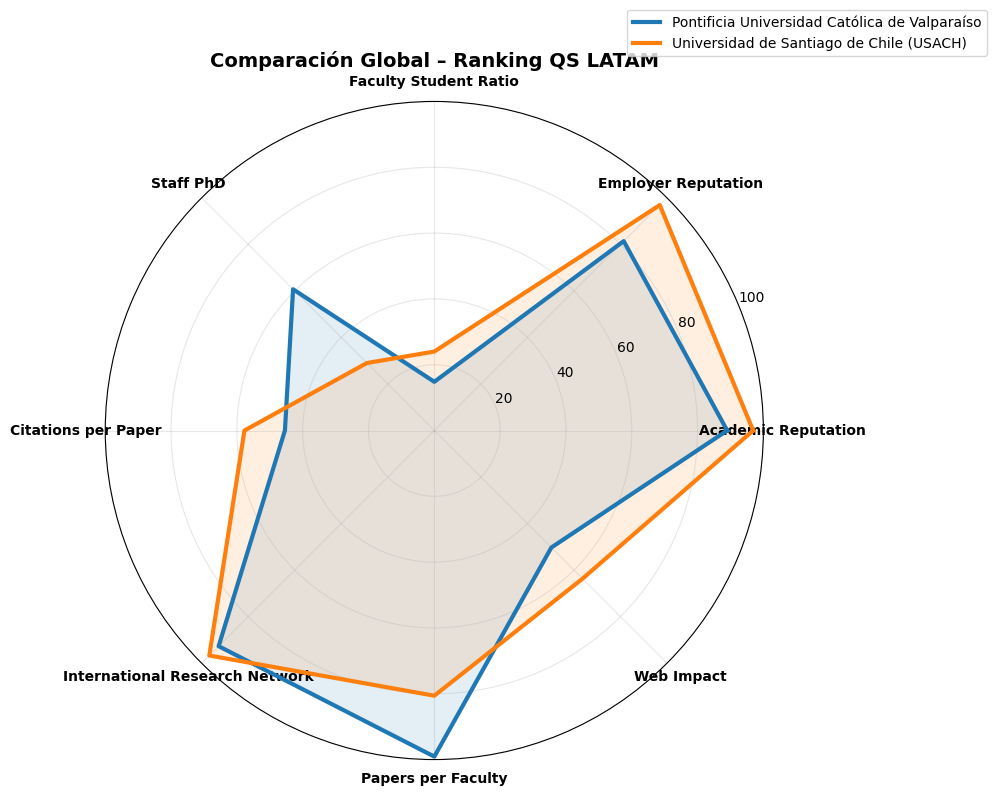


📊 PUNTAJES TOTALES (SITUACIÓN INICIAL)
────────────────────────────────────────────────────────────────────────────────
🏫 Pontificia Universidad Católica de Valparaíso (Referencia): 71.8
🔴 Universidad de Santiago de Chile (USACH): 76.4 → por ENCIMA por 4.6 puntos

🔍 VARIABLES INDIVIDUALES
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Variable                                          Pontificia Universid     Universidad de Santi
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Academic Reputation (30%)                                    89.0  🔴 ↓                     96.9
Employer Reputation (20%)                                    81.4  🔴 ↓                     96.9
Faculty Student Ratio (10%)                                  14.8  🔴 ↓                     24.0
Staff PhD (10%)                                              60.7  🟢 ↑             

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# VARIABLES Y PESOS (QS LATAM)
# ======================================================

VARIABLES = {
    'academic_reputation_score': 0.30,      # 30%
    'employer_reputation_score': 0.20,      # 20%
    'faculty_student_ratio_score': 0.10,    # 10%
    'staff_phd_score': 0.10,                # 10%
    'citations_per_paper_score': 0.10,      # 10%
    'international_research_network_score': 0.10,  # 10%
    'papers_per_faculty_score': 0.05,       # 5%
    'web_impact_score': 0.05                # 5%
}

NOMBRES = {
    'academic_reputation_score': 'Academic Reputation',
    'employer_reputation_score': 'Employer Reputation',
    'faculty_student_ratio_score': 'Faculty Student Ratio',
    'staff_phd_score': 'Staff PhD',
    'citations_per_paper_score': 'Citations per Paper',
    'international_research_network_score': 'International Research Network',
    'papers_per_faculty_score': 'Papers per Faculty',
    'web_impact_score': 'Web Impact'
}

# ======================================================
# FUNCIONES BASE
# ======================================================

def calcular_score(row, variable_extra=None, valor_extra=None):
    score = 0
    for col, peso in VARIABLES.items():
        valor = pd.to_numeric(row[col], errors='coerce')
        if pd.isna(valor):
            valor = 0

        if variable_extra and col == variable_extra:
            valor = valor_extra

        score += valor * peso
    return score

def radar(datos, nombres):
    """Genera gráfico radar para comparación visual"""
    vars_ = list(VARIABLES.keys())
    labels = [NOMBRES[v] for v in vars_]

    angles = np.linspace(0, 2*np.pi, len(vars_), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(10, 8))
    ax = plt.subplot(111, polar=True)

    # Colores para las líneas
    colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, (d, n) in enumerate(zip(datos, nombres)):
        values = [d.get(v, 0) for v in vars_] + [d.get(vars_[0], 0)]
        ax.plot(angles, values, linewidth=3, label=n, color=colores[i % len(colores)])
        ax.fill(angles, values, alpha=0.12, color=colores[i % len(colores)])

    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.set_title("Comparación Global – Ranking QS LATAM", pad=25, fontsize=14, fontweight='bold')
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ======================================================
# ANÁLISIS ESTRATÉGICO (MEJORADO)
# ======================================================

def analisis_estrategico_avanzado(uni1_data, uni2_data, nombre_uni1, nombre_uni2):
    """
    Análisis que considera: impacto, dificultad y potencial real
    """

    # Definir dificultad de mejora por tipo de variable
    dificultad = {
        'academic_reputation_score': 0.9,        # Muy difícil - toma años construir
        'employer_reputation_score': 0.8,        # Difícil - relaciones con empresas
        'citations_per_paper_score': 0.7,        # Media-alta - publicaciones de calidad
        'international_research_network_score': 0.6,  # Media - colaboraciones
        'staff_phd_score': 0.5,                  # Media - contratar doctores
        'faculty_student_ratio_score': 0.4,      # Media-baja - contratar profesores
        'papers_per_faculty_score': 0.3,         # Baja-media - incentivar publicación
        'web_impact_score': 0.2                  # Baja - mejorar presencia web
    }

    estrategias = []

    for col, peso in VARIABLES.items():
        # Convertir a numérico y manejar NaN
        valor_uni1 = pd.to_numeric(uni1_data.get(col, 0), errors='coerce')
        valor_uni2 = pd.to_numeric(uni2_data.get(col, 0), errors='coerce')

        if pd.isna(valor_uni1):
            valor_uni1 = 0
        if pd.isna(valor_uni2):
            valor_uni2 = 0

        diferencia = valor_uni2 - valor_uni1

        # Calcular mejora máxima realista (depende de la dificultad)
        mejora_maxima_realista = (100 - valor_uni1) * (1 - dificultad[col])
        mejora_optima = min(abs(diferencia), mejora_maxima_realista) if diferencia > 0 else mejora_maxima_realista * 0.5

        impacto = mejora_optima * peso
        eficiencia = impacto / (dificultad[col] + 0.1)  # +0.1 para evitar división por 0

        if diferencia > 0:  # Vamos detrás
            estrategias.append((col, diferencia, impacto, eficiencia, "RECUPERAR", mejora_optima))
        else:  # Vamos adelante
            estrategias.append((col, abs(diferencia), impacto, eficiencia, "CONSOLIDAR", mejora_optima))

    # Ordenar por eficiencia (impacto/dificultad)
    estrategias.sort(key=lambda x: x[3], reverse=True)

    print(f"\n🎯 RUTA ESTRATÉGICA ÓPTIMA PARA {nombre_uni1}")
    print("=" * 100)
    print("┌──────────────────────────────────┬──────────┬──────────┬──────────┬────────────┬──────────┐")
    print(f"│ {'Variable':<32} │ {'Brecha':>8} │ {'Impacto':>8} │ {'Eff':>6} │ {'Acción':<10} │ {'Meta':>8} │")
    print("├──────────────────────────────────┼──────────┼──────────┼──────────┼────────────┼──────────┤")

    for col, brecha, impacto, eff, accion, meta in estrategias[:]:
        nombre_completo = NOMBRES.get(col, col)
        if len(nombre_completo) > 32:
            nombre_completo = nombre_completo[:29] + "..."

        print(f"│ {nombre_completo:<32} │ {brecha:>8.1f} │ {impacto:>8.3f} │ {eff:>6.1f} │ {accion:<10} │ {meta:>7.1f} │")

    print("└──────────────────────────────────┴──────────┴──────────┴──────────┴────────────┴──────────┘")

    # Recomendación principal
    if estrategias:
        mejor_opcion = estrategias[0]
        nombre_mejor_opcion = NOMBRES.get(mejor_opcion[0], mejor_opcion[0])

        print(f"\n💡 RECOMENDACIÓN PRINCIPAL: Enfócate en {nombre_mejor_opcion}")
        print(f"   📊 Justificación:")
        print(f"   - Eficiencia: {mejor_opcion[3]:.1f} (impacto vs dificultad)")
        print(f"   - Meta realista: +{mejor_opcion[5]:.1f} puntos")
        print(f"   - Impacto en ranking: +{mejor_opcion[2]:.3f} puntos")

        # Análisis de escenarios
        print(f"\n📈 ESCENARIOS ESTRATÉGICOS:")

        # Escenario conservador (top 3 más eficientes)
        impacto_total = sum(estrategia[2] for estrategia in estrategias[:3])
        print(f"   🟢 ESCENARIO CONSERVADOR (1 año):")
        print(f"      Invertir en top 3 variables más eficientes")
        print(f"      Ganancia estimada: +{impacto_total:.2f} puntos")

        # Escenario agresivo (top 6)
        print(f"   🟡 ESCENARIO AGRESIVO (2-3 años):")
        impacto_total_agresivo = sum(estrategia[2] for estrategia in estrategias[:6])
        print(f"      Inversión integral en 6 variables clave")
        print(f"      Ganancia estimada: +{impacto_total_agresivo:.2f} puntos")

        # Puntos necesarios para superar
        score_actual_uni1 = calcular_score(uni1_data)
        score_actual_uni2 = calcular_score(uni2_data)
        puntos_para_superar = score_actual_uni2 - score_actual_uni1

        if puntos_para_superar > 0:
            print(f"\n🎯 OBJETIVO: Superar a {nombre_uni2}")
            print(f"   - Necesitas: +{puntos_para_superar:.2f} puntos")
            print(f"   - Con escenario conservador: {'✅ POSIBLE' if impacto_total >= puntos_para_superar else '⚠️  PARCIAL'}")
            print(f"   - Con escenario agresivo: {'✅ GARANTIZADO' if impacto_total_agresivo >= puntos_para_superar else '✅ POSIBLE'}")

# ======================================================
# COMPARADOR PRINCIPAL (MEJORADO)
# ======================================================

def comparar(df, indices, simular=False):
    """Función principal de comparación"""
    datos = [df.iloc[i].copy() for i in indices]
    nombres = [d['title'] for d in datos]

    # Mostrar gráfico radar si hay 2-4 universidades
    if 2 <= len(datos) <= 4:
        print("\n📊 GENERANDO GRÁFICO RADAR DE COMPARACIÓN...")
        radar(datos, nombres)

    scores = [calcular_score(d) for d in datos]

    print("\n📊 PUNTAJES TOTALES (SITUACIÓN INICIAL)")
    print("─" * 80)

    print(f"🏫 {nombres[0]} (Referencia): {scores[0]:.1f}")
    for i in range(1, len(scores)):
        brecha = scores[i] - scores[0]
        icon = "🔴" if brecha > 0 else "🟢" if brecha < 0 else "⚪"
        estado = "por ENCIMA" if brecha > 0 else "por DEBAJO" if brecha < 0 else "EMPATA"
        print(f"{icon} {nombres[i]}: {scores[i]:.1f} → {estado} por {abs(brecha):.1f} puntos")

    # ==================================================
    # TABLA VARIABLES DETALLADA
    # ==================================================

    print("\n🔍 VARIABLES INDIVIDUALES")
    print("─" * 120)

    # Encabezado
    header = f"{'Variable':45}"
    for n in nombres:
        header += f"{n[:20]:>25}"
    print(header)
    print("─" * 120)

    for v, peso in VARIABLES.items():
        fila = f"{NOMBRES[v]} ({peso*100:.0f}%)".ljust(45)

        if len(datos) == 2:
            v1, v2 = datos[0].get(v, 0), datos[1].get(v, 0)
            if v1 > v2:
                emoji = "🟢 ↑"
            elif v1 < v2:
                emoji = "🔴 ↓"
            else:
                emoji = "⚪ ="
            fila += f"{v1:>20.1f} {emoji:>4}{v2:>25.1f}"
        else:
            for d in datos:
                fila += f"{d.get(v, 0):>25.1f}"

        print(fila)

    # ==================================================
    # SIMULACIÓN
    # ==================================================

    if simular and len(datos) >= 1:
        print("\n🔄 SIMULACIÓN DE MEJORA")
        vars_list = list(VARIABLES.keys())

        for i, v in enumerate(vars_list, 1):
            print(f"{i:2d}. {NOMBRES[v]}")

        try:
            idx = int(input("\nSelecciona variable a mejorar (número): ")) - 1
            if 0 <= idx < len(vars_list):
                var = vars_list[idx]
                pct = float(input("Porcentaje de mejora (ej: 10 para 10%): "))

                base = datos[0].get(var, 0)
                nuevo_valor = min(base * (1 + pct / 100), 100)
                datos[0][var] = nuevo_valor

                nuevo_score = calcular_score(datos[0])

                print(f"\n📈 RESULTADO DE LA SIMULACIÓN")
                print(f"• Variable mejorada: {NOMBRES[var]}")
                print(f"• Valor original: {base:.1f}")
                print(f"• Valor simulado: {nuevo_valor:.1f} (+{pct}%)")
                print(f"• Score original: {scores[0]:.2f}")
                print(f"• Score simulado: {nuevo_score:.2f}")
                print(f"• Ganancia total: +{nuevo_score - scores[0]:.2f} puntos")

                if len(datos) == 2:
                    nueva_brecha = scores[1] - nuevo_score
                    if nuevo_score > scores[1] and scores[0] <= scores[1]:
                        print(f"• 🎉 ¡CAMBIO DE POSICIÓN! Ahora supera a {nombres[1]}")
                    elif nuevo_score > scores[1]:
                        print(f"• 📈 Amplía su ventaja sobre {nombres[1]}")
                    else:
                        print(f"• ⚠️  Sigue por debajo de {nombres[1]}")
                        print(f"• 💡 Necesita {abs(nueva_brecha):.2f} puntos más para superarla")
            else:
                print("❌ Número fuera de rango")
        except (ValueError, IndexError):
            print("❌ Opción inválida")

    # ==================================================
    # ANÁLISIS ESTRATÉGICO (solo para 2 universidades)
    # ==================================================

    if len(datos) == 2:
        analisis_estrategico_avanzado(datos[0], datos[1], nombres[0], nombres[1])

    # ==================================================
    # EXPLICACIONES FINALES
    # ==================================================

    print("\n📘 LEYENDA Y EXPLICACIONES")
    print("─" * 60)
    print("• 🟢 Verde: la universidad de referencia está mejor posicionada")
    print("• 🔴 Rojo: la universidad de referencia está peor posicionada")
    print("• ↑/↓: indica dirección de la ventaja")
    print("• Brecha: diferencia en puntaje total respecto a la referencia")
    print("• Impacto: mejora potencial × peso en el ranking")
    print("• Eff (Eficiencia): impacto ajustado por dificultad de mejora")
    print("• Meta: incremento máximo realista considerando restricciones")

# ======================================================
# INTERFAZ INTERACTIVA (MEJORADA)
# ======================================================

def comparador_interactivo():
    """Versión interactiva para comparar cualquier par de universidades"""
    try:
        df = pd.read_csv('ranking_qs_latam_chile_calculado.csv')
        print("✅ Datos cargados correctamente")
        print(f"📊 Total de universidades: {len(df)}")
    except FileNotFoundError:
        print("❌ Error: No se encontró el archivo 'ranking_qs_latam_chile_calculado.csv'")
        print("💡 Asegúrate de que el archivo esté en la misma carpeta")
        return

    while True:
        print("\n" + "="*80)
        print("🏫 COMPARADOR INTERACTIVO DE UNIVERSIDADES CHILENAS QS LATAM")
        print("="*80)

        print("\n📋 UNIVERSIDADES DISPONIBLES:")
        for i, nombre in enumerate(df['title'], 1):
            print(f"   {i:2d}. {nombre}")

        print("\n🔍 Selecciona universidades a comparar:")
        print("   Ejemplo: '1,3' para comparar universidad 1 con 3")
        print("           '1,2,4' para comparar 3 universidades")
        print("           'salir' para terminar")

        sel = input("\nSelección: ").strip()

        if sel.lower() == 'salir':
            break

        try:
            indices = [int(x.strip()) - 1 for x in sel.split(",")]

            # Validar índices
            if any(idx < 0 or idx >= len(df) for idx in indices):
                print("❌ Uno o más índices están fuera de rango")
                continue

            if len(indices) < 1:
                print("❌ Debes seleccionar al menos una universidad")
                continue

            if len(indices) > 4:
                print("⚠️  Advertencia: Para mejores resultados, compara máximo 4 universidades")

            # Preguntar por simulación solo si hay al menos 1 universidad
            sim = False
            if len(indices) >= 1:
                sim_input = input("¿Deseas simular una mejora en la primera universidad? (s/n): ").lower()
                sim = sim_input == "s"

            # Ejecutar comparación
            comparar(df, indices, sim)

            # Preguntar si continuar
            continuar = input("\n¿Quieres hacer otra comparación? (s/n): ").strip().lower()
            if continuar != 's':
                break

        except ValueError:
            print("❌ Formato inválido. Usa números separados por comas")
        except Exception as e:
            print(f"❌ Error: {e}")

def comparacion_rapida(uni1, uni2, archivo='ranking_qs_latam_chile_calculado.csv'):
    """Función para comparación rápida sin modo interactivo"""
    try:
        df = pd.read_csv(archivo)

        # Buscar universidades
        mask1 = df['title'].str.contains(uni1, case=False, na=False)
        mask2 = df['title'].str.contains(uni2, case=False, na=False)

        if not mask1.any() or not mask2.any():
            print("❌ Una o ambas universidades no encontradas")
            return None, None

        idx1 = df[mask1].index[0]
        idx2 = df[mask2].index[0]

        comparar(df, [idx1, idx2], simular=False)
        return df.iloc[idx1], df.iloc[idx2]

    except FileNotFoundError:
        print(f"❌ No se encontró el archivo {archivo}")
        return None, None

# ======================================================
# EJECUCIÓN PRINCIPAL
# ======================================================

if __name__ == "__main__":
    print("🚀 INICIANDO COMPARADOR AVANZADO DE UNIVERSIDADES QS LATAM")
    print("="*80)
    print("💡 Características:")
    print("   • Gráficos radar para visualización comparativa")
    print("   • Análisis estratégico con recomendaciones específicas")
    print("   • Simulación de mejoras con impacto estimado")
    print("   • Comparación de 2 a 4 universidades simultáneamente")
    print("="*80)

    comparador_interactivo()